# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

Group name:  
Created by Tamanna Singh 016309137 Angie Avalos Joel 015752230
Last updated: MARCH 29 2026  

### Q1: How clean is your data?  
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

**There are several columns that contain null values but none are particularly concerning to our questions (tagline, director, cast). This will be solved by converting values to numeric (to_numeric) or fillinf them (fillna). There are no formatiing concerns or inconsistent data.**

### Q2: Create a categorical plot
Come up with a unique question that can be answer using a categorical plot from the sns module

**What is the distribution of vote average for movie language?**

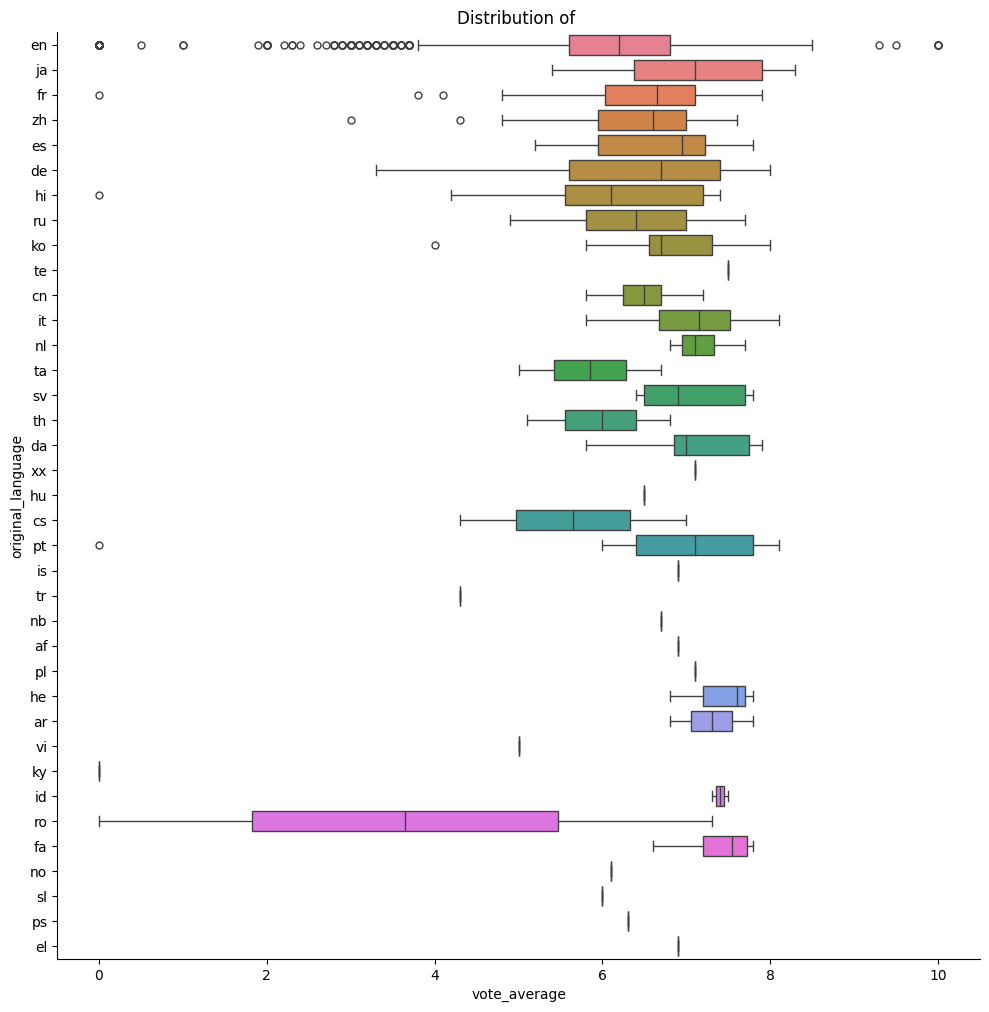

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('movies.csv')
#df.head()

sns.catplot(
    data=df,
    x="vote_average",
    y="original_language",
    aspect=1, # aspect change the aspect ratio
    kind="box",
    height=10,
    # palette="Paired"
    hue="original_language",
    #palette=,
    # dodge=False # dodge controls overlap of the plots
    )
plt.title("Distribution of ");

### Q3: Come up with a another unique question. This question must use map() or apply()

**What is the most common main genre of movie?**

<Axes: xlabel='count', ylabel='main_genre'>

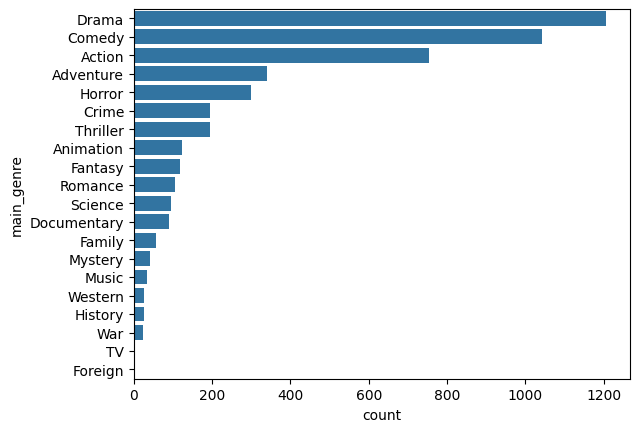

In [3]:
df["genres"] = df["genres"].fillna("")
df["main_genre"] = df["genres"].apply(lambda x: x.split()[0] if x != "" else None)

sns.countplot(data=df, y="main_genre", order=df["main_genre"].value_counts().index)

### Q4: Create an interactive plot
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

**How strongly does production budget influence box office revenue?**

In [4]:
import numpy as np
import pandas as pd

# plotly libraries
from plotly.offline import init_notebook_mode, iplot, plot
import plotly as py
init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.express as px

# matplotlib
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

### If running plotly in Google colab, you will need to run this custom initialization function
### in each offline plotting cell to embed HTML content in Jupyter notebook
def configure_plotly_browser_state():
  import IPython
  display(IPython.core.display.HTML('''
        <script src="/static/components/requirejs/require.js"></script>
        <script>
          requirejs.config({
            paths: {
              base: '/static/base',
              plotly: 'https://cdn.plot.ly/plotly-latest.min.js?noext',
            },
          });
        </script>
        '''))


configure_plotly_browser_state()

px.scatter(df,
           x="budget",
           y="revenue",
           color="main_genre",
           size="popularity",
           hover_data=["title", "vote_average"],
           title="Budget vs Revenue of Movies"
           )


**This interactive plot allows users to explore the relationship between movie production budget and box office revenue more deeply than a static plot. When users over over each point several details are shown such as movie title, populrity, and genre. This provides context behind outliers or trends. Interactive plots also allows users to zoom in on clusters mkaing it easier to identify patterns that might not be visible in a static plot.**

## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?

### What additional datasets would you need to find or create to help strengthen your data?
In order to strengthen the data the movies_metadata.csv can be used as it has information about whether the movie is aimed specifically to adults or the general audience, states if a movie is part of a franchise or series, gives a link to the IMDb, the genres is more strutured with JSON lists, and has information on popularity and ratings which gives more information compared to vote_average or vote_count. It organizes the data and production companies more while showing if the movie is part of a collection or not which gives more information about why a movie is popular or not such as it being part of a triliogy or not. It can lead to movie filtering based on whether the movie is for adults or a general audicne. 
### How would you combine the dataset 
In order to merge the dataset is to use the ids such as the id andn imdb_id if there is a mismatch then the movie title or the relase year can be used to combine the dataset. 

movies_df = pd.read_csv("movies.csv")
metadata_df = pd.read_csv("movies_metadata.csv")
combined_df = movies_df.merge(metadata_df, on="id", how="outer")
## DO you need to reshape your data and how would you go about it?
We need to reshape data as some of the columns such as productin companies and more are stored as dictionaries which must be changed so that the data can be accessed. 

df['genre_names'] = df['genres'].apply(lambda x: [g['name'] for g in eval(x)] if pd.notnull(x) else [])


  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   --------------------------------------- 527.0/527.0 kB 17.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/625.2 kB ? eta -:--:--
   --------------------------------------- 625.2/625.2 kB 22.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/27.6 MB ? eta -:--:--
   --------- ------------------------------ 6.8/27.6 MB 32.1 MB/s eta 0:00:01
   ---------------- ----------------------- 11.5/27.6 MB 27.7 MB/s eta 0:00:01
   ----------------------- ---------------- 16.5/27.6 MB 26.0 MB/s eta 0:00:01
   ------------------------------------ --- 25.4/27.6 MB 30.4 MB/s eta 0:00:01
   ---------------------------------------- 27.6/27.6 MB 30.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---------------------------------------- 3.7/3.7 MB 55.0 MB/s eta 0:00:00
Using cached click-8.3.1-p

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
task-manager 6.6.0 requires email-validator==1.1.3, but you have email-validator 2.3.0 which is incompatible.
task-manager 6.6.0 requires Flask==2.0.3, but you have flask 3.0.3 which is incompatible.
task-manager 6.6.0 requires python-dotenv==0.19.2, but you have python-dotenv 1.0.1 which is incompatible.
task-manager 6.6.0 requires requests==2.27.1, but you have requests 2.32.3 which is incompatible.
task-manager 6.6.0 requires SQLAlchemy==1.4.32, but you have sqlalchemy 2.0.36 which is incompatible.
task-manager 6.6.0 requires Werkzeug==2.0.3, but you have werkzeug 3.1.4 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


NameError: name 'load_huggingface_dataset' is not defined